In [ ]:
import openmc
import openmc.deplete
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# ==========================
# Définition des matériaux
# ==========================

# Combustible MOX (UO2-PuO2)
UGD_fuel = openmc.Material(name='UGD Fuel')
UGD_fuel.add_nuclide('U238', 0.924)
UGD_fuel.add_nuclide('U235', 0.036)
UGD_fuel.add_element('Gd', 0.04)
UGD_fuel.set_density('g/cm3', 10.5)
UGD_fuel.temperature = 1200  # Température en K
UGD_fuel.volume = 144.96

def mox_fuel(enrichment):
    """Créer un matériau MOX avec un enrichissement donné en Pu239."""
    mox = openmc.Material()
    mox.add_element('U', 0.91)
    mox.add_nuclide('Pu239', enrichment)
    mox.add_nuclide('Pu240', 0.035)
    mox.add_nuclide('Pu241', 0.005)
    mox.add_nuclide('Pu242', 0.005)
    mox.add_nuclide('O16', 2.00)
    mox.set_density('g/cm3', 10.5)
    mox.temperature = 1200
    mox.volume = 144.96
    return mox

mox_3_6 = mox_fuel(0.08)
mox_2_7 = mox_fuel(0.067)
mox_2_4 = mox_fuel(0.052)

# Caloporteur Sodium
sodium = openmc.Material(name='Sodium')
sodium.add_nuclide('Na23', 1.0)
sodium.set_density('g/cm3', 0.4635)
sodium.temperature = 600  # Température en K

# Gainage en zirconium
zirconium_cladding = openmc.Material(name='Zirconium Cladding')
zirconium_cladding.add_element('Zr', 1.0)
zirconium_cladding.set_density('g/cm3', 6.5)
zirconium_cladding.temperature = 900  # Température en K

# Gaz d'Hélium
gas_gap = openmc.Material(name='Helium Gap')
gas_gap.add_element('He', 1.0)
gas_gap.set_density('g/cm3', 0.0001786)
gas_gap.temperature = 900  # Température en K

# Définition des matériaux
materials = openmc.Materials([UGD_fuel, mox_3_6, mox_2_7, mox_2_4, sodium, gas_gap, zirconium_cladding])
materials.export_to_xml()

# ===========================
# Définition de la géométrie
# ===========================

pin_pitch = 1.25984
fuel_radius = openmc.ZCylinder(r=0.39218)
clad_inner_radius = openmc.ZCylinder(r=0.40005)
clad_outer_radius = openmc.ZCylinder(r=0.45720)
#outzone_sodium = openmc.ZCylinder(r=pin_pitch/2)

N = 11  # Nombre de couronnes de crayons
assembly_width = (N-1) * pin_pitch * sqrt(3)
assembly_pitch = assembly_width + 0.5

pin_box = openmc.model.HexagonalPrism(edge_length=pin_pitch/2, boundary_type='reflective')
assembly_box = openmc.model.HexagonalPrism(edge_length=30, boundary_type='reflective')

mox_3_6_cell = openmc.Cell(name='Fuel1', fill=mox_3_6, region=-fuel_radius)
mox_2_7_cell = openmc.Cell(name='Fuel2', fill=mox_2_7, region=-fuel_radius)
mox_2_4_cell = openmc.Cell(name='Fuel3', fill=mox_2_4, region=-fuel_radius)

UGD_cell = openmc.Cell(name='UGd', fill=UGD_fuel, region=-fuel_radius)
guide_tube_cell = openmc.Cell(name='Guide Tube',fill=zirconium_cladding, region=-clad_outer_radius)

gap_3_6_cell = openmc.Cell(name='Helium 3.6 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_2_7_cell = openmc.Cell(name='Helium 2.7 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_2_4_cell = openmc.Cell(name='Helium 2.4 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_Ugd_cell = openmc.Cell(name='Helium Ugd Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)

clad_3_6_cell = openmc.Cell(name='Cladding 3.6', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_2_7_cell = openmc.Cell(name='Cladding 2.7', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_2_4_cell = openmc.Cell(name='Cladding 2.4', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_Ugd_cell = openmc.Cell(name='Cladding Ugd', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)

sodium_inner_3_6_cell = openmc.Cell(name='Coolant 3.6 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_2_7_cell = openmc.Cell(name='Coolant 2.7 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_2_4_cell = openmc.Cell(name='Coolant 2.4 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_Ugd_cell = openmc.Cell(name='Coolant Ugd inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_GT_cell = openmc.Cell(name='Coolant GT inner', fill=sodium, region=+clad_outer_radius)

sodium_outer_cell = openmc.Cell(name='Coolant outer', fill=sodium)

sodium_universe = openmc.Universe(cells=[sodium_outer_cell])
guide_tube_universe = openmc.Universe(cells=[guide_tube_cell,sodium_inner_GT_cell])

mox_3_6_universe = openmc.Universe(cells=[mox_3_6_cell, gap_3_6_cell, clad_3_6_cell,sodium_inner_3_6_cell])
mox_2_7_universe = openmc.Universe(cells=[mox_2_7_cell, gap_2_7_cell, clad_2_7_cell,sodium_inner_2_7_cell])
mox_2_4_universe = openmc.Universe(cells=[mox_2_4_cell, gap_2_4_cell, clad_2_4_cell,sodium_inner_2_4_cell])
UGD_universe = openmc.Universe(cells=[UGD_cell, gap_Ugd_cell, clad_Ugd_cell,sodium_inner_Ugd_cell])

lattice = openmc.HexLattice(lattice_id=200)
lattice.center = (0.0, 0.0)
lattice.pitch = [pin_pitch]
lattice.outer = sodium_universe
lattice.universes = [
    ([mox_2_4_universe] + [mox_2_7_universe] * 9) * 6,
    ([UGD_universe] + [mox_3_6_universe] * 8 ) * 6,
    ([mox_3_6_universe] * 4 + [UGD_universe] + [mox_3_6_universe] * 3) * 6,
    ([mox_3_6_universe] * 7) * 6,
    ([mox_3_6_universe] * 3 + [guide_tube_universe] + [mox_3_6_universe] * 2) * 6,
    ([guide_tube_universe] + [mox_3_6_universe] * 4) * 6,
    ([mox_3_6_universe] * 3 + [UGD_universe]) * 6,
    ([guide_tube_universe] + [mox_3_6_universe] + [mox_3_6_universe]) * 6,
    ([mox_3_6_universe] + [mox_3_6_universe]) * 6,
    [mox_3_6_universe] * 6,
    [guide_tube_universe]
]



assembly_cell = openmc.Cell(fill=lattice, region=-assembly_box)
root_universe = openmc.Universe(cells=[assembly_cell])
geometry = openmc.Geometry(root_universe)
geometry.export_to_xml()

# ===========================
# Définition de la physique
# ===========================

source = openmc.Source()
source.space = openmc.stats.Point(
    (0, -pin_pitch, 0.0)  # Point
)
source.angle = openmc.stats.Isotropic()
source.energy = openmc.stats.Watt(a=0.988, b=2.249)

settings = openmc.Settings()
settings.batches = 50
settings.inactive = 10
settings.particles = 10000
settings.source = source
settings.run_mode = 'eigenvalue'
settings.temperature = {'method': 'interpolation', 'range': (300, 1200)} # Interpolation des XS pour les températures inexistantes dans l'ENDF/B-VII.1
settings.export_to_xml()

# ===========================
# Vérification de la géométrie
# ===========================

plot_xy = openmc.Plot(plot_id=1)
plot_xy.filename = 'plot_xy'
plot_xy.origin = [0, 0, 0]
plot_xy.width = [6, 6]
plot_xy.pixels = [400, 400]
plot_xy.color_by = 'material'

plot_yz = openmc.Plot(plot_id=2)
plot_yz.filename = 'plot_yz'
plot_yz.basis = 'yz'
plot_yz.origin = [0, 0, 0]
plot_yz.width = [40, 40]
plot_yz.pixels = [400, 400]
plot_yz.color_by = 'material'

# Instantiate a Plots collection, add plots, and export to XML
plot_file = openmc.Plots((plot_xy, plot_yz))
plot_file.export_to_xml()

# ===========================
# Définition du modèle OpenMC avec variation
# ===========================

burnup_points = (1.00000000e-04, 4.28580714e+00, 8.57151429e+00, 1.28572214e+01,
 1.71429286e+01, 2.14286357e+01, 2.57143429e+01, 3.00000500e+01,
 3.42857571e+01, 3.85714643e+01)


keff_values = []
keff_errors = []

depletion_chain = openmc.deplete.Chain.from_xml("chain_endfb71_sfr.xml")
model = openmc.Model(geometry=geometry, settings=settings, materials=materials)
operator = openmc.deplete.CoupledOperator(model, chain_file="chain_endfb71_sfr.xml")



for step in range(len(burnup_points)):
    sp = openmc.StatePoint(f'openmc_simulation_n{step+1}.h5')
    keff = sp.k_combined
    keff_values.append(keff.nominal_value)
    keff_errors.append(keff.std_dev)
    sp.close()

plt.errorbar(burnup_points, keff_values, yerr=keff_errors, fmt='o-', capsize=5, label="k-eff")
plt.xlabel("Burnup (GJ/t)")
plt.ylabel("k-eff")
plt.title("Évolution de k-eff en fonction du burnup")
plt.grid()
plt.legend()
plt.show()


Univers 1: Universe
	ID             =	3
	Name           =	
	Geom           =	CSG
	Cells          =	[1, 6, 10, 14]
 (Type: <class 'openmc.universe.Universe'>)
Univers 2: Universe
	ID             =	4
	Name           =	
	Geom           =	CSG
	Cells          =	[2, 7, 11, 15]
 (Type: <class 'openmc.universe.Universe'>)
Univers 3: Universe
	ID             =	5
	Name           =	
	Geom           =	CSG
	Cells          =	[3, 8, 12, 16]
 (Type: <class 'openmc.universe.Universe'>)
Univers 4: Universe
	ID             =	6
	Name           =	
	Geom           =	CSG
	Cells          =	[4, 9, 13, 17]
 (Type: <class 'openmc.universe.Universe'>)


KeyError: 'No material exists with ID=1.'

In [ ]:
import openmc
import matplotlib.pyplot as plt
import numpy as np

burnup_points = np.linspace(0.0001, 60, 15)
burnup_points = burnup_points[:-5]
print(burnup_points)

keff_values = []
keff_errors = []
for step in range(9):
    sp = openmc.StatePoint(f'openmc_simulation_n{step+1}.h5')
    keff = sp.k_combined
    print(keff.nominal_value)
    keff_values.append(keff.nominal_value)
    keff_errors.append(keff.std_dev)
    sp.close()

print(keff_values)
print(keff_errors)


[1.00000000e-04 4.28580714e+00 8.57151429e+00 1.28572214e+01
 1.71429286e+01 2.14286357e+01 2.57143429e+01 3.00000500e+01
 3.42857571e+01 3.85714643e+01 4.28571714e+01]
0.9164114672179005
0.8473747445221763


/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


0.8167784900095804
0.7851200403444879
0.7551512967869326


/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


0.7214886594951482
0.686628541799777
0.6434980827890494
0.5965162694202613
[0.9164114672179005, 0.8473747445221763, 0.8167784900095804, 0.7851200403444879, 0.7551512967869326, 0.7214886594951482, 0.686628541799777, 0.6434980827890494, 0.5965162694202613]
[0.0007952820466524422, 0.0006305735025148555, 0.000625471008416775, 0.0006136950637971477, 0.0006184542303602417, 0.000595045019042615, 0.0005219691768578445, 0.000486032546926751, 0.00041381955813641713]


/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


Univers 1: Universe
	ID             =	3
	Name           =	
	Geom           =	CSG
	Cells          =	[1, 6, 10, 14]
 (Type: <class 'openmc.universe.Universe'>)
Univers 2: Universe
	ID             =	4
	Name           =	
	Geom           =	CSG
	Cells          =	[2, 7, 11, 15]
 (Type: <class 'openmc.universe.Universe'>)
Univers 3: Universe
	ID             =	5
	Name           =	
	Geom           =	CSG
	Cells          =	[3, 8, 12, 16]
 (Type: <class 'openmc.universe.Universe'>)
Univers 4: Universe
	ID             =	6
	Name           =	
	Geom           =	CSG
	Cells          =	[4, 9, 13, 17]
 (Type: <class 'openmc.universe.Universe'>)
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %

/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/source.py:656: FutureWarning: This class is deprecated in favor of 'IndependentSource'
  warnings.warn("This class is deprecated in favor of 'IndependentSource'", FutureWarning)


 Reading U238 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/U238.h5
 Reading Pu239 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Pu239.h5
 Reading Pu240 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Pu240.h5
 Reading Pu241 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Pu241.h5
 Reading Pu242 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Pu242.h5
 Reading O16 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/O16.h5
 Reading Gd152 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Gd152.h5
 Reading Gd154 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Gd154.h5
 Reading Gd155 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Gd155.h5
 Reading Gd156 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Gd156.h5
 Reading Gd157 from
 /Users/damienquillaud/ope

 Reading Mg26 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Mg26.h5
 Reading Al27 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Al27.h5
 Reading Si28 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Si28.h5
 Reading Si29 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Si29.h5
 Reading Si30 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Si30.h5
 Reading P31 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/P31.h5
 Reading S32 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/S32.h5
 Reading S33 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/S33.h5
 Reading S34 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/S34.h5
 Reading S36 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/S36.h5
 Reading Cl35 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii

 Reading K39 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/K39.h5
 Reading K40 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/K40.h5
 Reading K41 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/K41.h5
 Reading Ca40 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Ca40.h5
 Reading Ca42 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Ca42.h5
 Reading Ca43 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Ca43.h5
 Reading Ca44 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Ca44.h5
 Reading Ca46 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Ca46.h5
 Reading Ca48 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Ca48.h5
 Reading Sc45 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Sc45.h5
 Reading Ti46 from
 /Users/damienquillaud/openmc/openmc/data/endfb

...

 Reading Gd153 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Gd153.h5
 Reading Tb159 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Tb159.h5
 Reading Tb160 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Tb160.h5
 Reading Dy156 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Dy156.h5
 Reading Dy158 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Dy158.h5
 Reading Dy160 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Dy160.h5
 Reading Dy161 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Dy161.h5
 Reading Dy162 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Dy162.h5
 Reading Dy163 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Dy163.h5
 Reading Dy164 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Dy164.h5
 Reading Ho165 from
 /Users/damienquilla

          1200K


 Reading Cf251 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Cf251.h5
 Reading Cf252 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Cf252.h5
 Reading Cf253 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Cf253.h5
 Reading Cf254 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Cf254.h5
 Reading Es251 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Es251.h5
 Reading Es252 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Es252.h5
 Reading Es253 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Es253.h5
 Reading Es254 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Es254.h5
 Reading Es254_m1 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Es254_m1.h5
 Reading Es255 from
 /Users/damienquillaud/openmc/openmc/data/endfb-vii.1-hdf5/neutron/Es255.h5
 Reading Fm255 from
 /Users/damien

/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(
/Users/damienquillaud/miniconda3/envs/openmc-env/lib/python3.12/site-packages/openmc/statepoint.py:277: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(
/Users/damienquillaud/miniconda3/envs/op

ValueError: 'x' and 'y' must have the same size

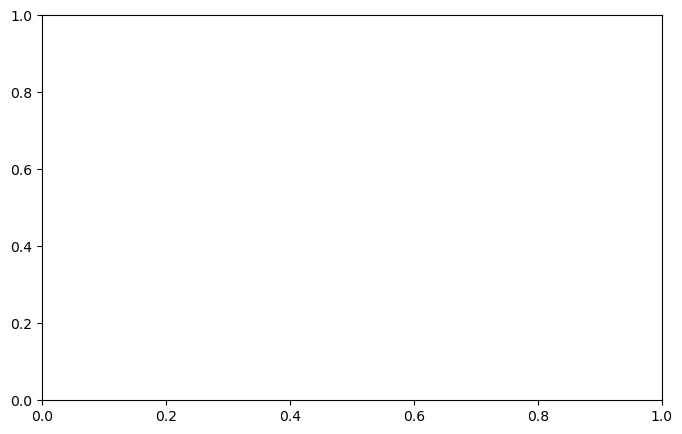

In [ ]:
import openmc
import openmc.deplete
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# ==========================
# Définition des matériaux
# ==========================

# Combustible MOX (UO2-PuO2)
UGD_fuel = openmc.Material(material_id= 4 ,name='UGD Fuel')
UGD_fuel.add_nuclide('U238', 0.924)
UGD_fuel.add_nuclide('U235', 0.036)
UGD_fuel.add_element('Gd', 0.04)
UGD_fuel.set_density('g/cm3', 10.5)
UGD_fuel.temperature = 1200  # Température en K
UGD_fuel.volume = 144
UGD_fuel.depletable=True


def mox_fuel(enrichment,ID):
    """Créer un matériau MOX avec un enrichissement donné en Pu239."""
    mox = openmc.Material(material_id=ID, name='MOX 3.6%')
    mox.add_element('U', 0.91)
    mox.add_nuclide('Pu239', enrichment)
    mox.add_nuclide('Pu240', 0.035)
    mox.add_nuclide('Pu241', 0.005)
    mox.add_nuclide('Pu242', 0.005)
    mox.add_nuclide('O16', 2.00)
    mox.set_density('g/cm3', 10.5)
    mox.temperature = 1200
    mox.volume = 144
    mox.depletable=True
    return mox

mox_3_6 = mox_fuel(0.08,1)
mox_2_7 = mox_fuel(0.067,2)
mox_2_4 = mox_fuel(0.052,3)

# Caloporteur Sodium
sodium = openmc.Material(name='Sodium')
sodium.add_nuclide('Na23', 1.0)
sodium.set_density('g/cm3', 0.0001)
sodium.temperature = 600  # Température en K

# Gainage en zirconium
zirconium_cladding = openmc.Material(name='Zirconium Cladding')
zirconium_cladding.add_element('Zr', 1.0)
zirconium_cladding.set_density('g/cm3', 6.5)
zirconium_cladding.temperature = 900  # Température en K

# Gaz d'Hélium
gas_gap = openmc.Material(name='Helium Gap')
gas_gap.add_element('He', 1.0)
gas_gap.set_density('g/cm3', 0.0001786)
gas_gap.temperature = 900  # Température en K

# Définition des matériaux
materials = openmc.Materials([UGD_fuel, mox_3_6, mox_2_7, mox_2_4, sodium, gas_gap, zirconium_cladding])
materials.export_to_xml()

# ===========================
# Définition de la géométrie
# ===========================

pin_pitch = 1.25984
fuel_radius = openmc.ZCylinder(r=0.39218)
clad_inner_radius = openmc.ZCylinder(r=0.40005)
clad_outer_radius = openmc.ZCylinder(r=0.45720)
#outzone_sodium = openmc.ZCylinder(r=pin_pitch/2)

N = 11  # Nombre de couronnes de crayons
assembly_width = (N-1) * pin_pitch * sqrt(3)
assembly_pitch = assembly_width + 0.5

pin_box = openmc.model.HexagonalPrism(edge_length=pin_pitch/2, boundary_type='reflective')
assembly_box = openmc.model.HexagonalPrism(edge_length=30, boundary_type='reflective')

mox_3_6_cell = openmc.Cell(name='Fuel1', fill=mox_3_6, region=-fuel_radius)
mox_2_7_cell = openmc.Cell(name='Fuel2', fill=mox_2_7, region=-fuel_radius)
mox_2_4_cell = openmc.Cell(name='Fuel3', fill=mox_2_4, region=-fuel_radius)

UGD_cell = openmc.Cell(name='UGd', fill=UGD_fuel, region=-fuel_radius)
guide_tube_cell = openmc.Cell(name='Guide Tube',fill=zirconium_cladding, region=-clad_outer_radius)

gap_3_6_cell = openmc.Cell(name='Helium 3.6 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_2_7_cell = openmc.Cell(name='Helium 2.7 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_2_4_cell = openmc.Cell(name='Helium 2.4 Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)
gap_Ugd_cell = openmc.Cell(name='Helium Ugd Gap', fill=gas_gap, region=+fuel_radius & -clad_inner_radius)

clad_3_6_cell = openmc.Cell(name='Cladding 3.6', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_2_7_cell = openmc.Cell(name='Cladding 2.7', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_2_4_cell = openmc.Cell(name='Cladding 2.4', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)
clad_Ugd_cell = openmc.Cell(name='Cladding Ugd', fill=zirconium_cladding, region=+clad_inner_radius & -clad_outer_radius)

sodium_inner_3_6_cell = openmc.Cell(name='Coolant 3.6 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_2_7_cell = openmc.Cell(name='Coolant 2.7 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_2_4_cell = openmc.Cell(name='Coolant 2.4 inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_Ugd_cell = openmc.Cell(name='Coolant Ugd inner', fill=sodium, region=+clad_outer_radius)
sodium_inner_GT_cell = openmc.Cell(name='Coolant GT inner', fill=sodium, region=+clad_outer_radius)

sodium_outer_cell = openmc.Cell(name='Coolant outer', fill=sodium)

sodium_universe = openmc.Universe(cells=[sodium_outer_cell])
guide_tube_universe = openmc.Universe(cells=[guide_tube_cell,sodium_inner_GT_cell])

mox_3_6_universe = openmc.Universe(cells=[mox_3_6_cell, gap_3_6_cell, clad_3_6_cell,sodium_inner_3_6_cell])
mox_2_7_universe = openmc.Universe(cells=[mox_2_7_cell, gap_2_7_cell, clad_2_7_cell,sodium_inner_2_7_cell])
mox_2_4_universe = openmc.Universe(cells=[mox_2_4_cell, gap_2_4_cell, clad_2_4_cell,sodium_inner_2_4_cell])
UGD_universe = openmc.Universe(cells=[UGD_cell, gap_Ugd_cell, clad_Ugd_cell,sodium_inner_Ugd_cell])

lattice = openmc.HexLattice(lattice_id=200)
lattice.center = (0.0, 0.0)
lattice.pitch = [pin_pitch]
lattice.outer = sodium_universe
lattice.universes = [
    ([mox_2_4_universe] + [mox_2_7_universe] * 9) * 6,
    ([UGD_universe] + [mox_3_6_universe] * 8 ) * 6,
    ([mox_3_6_universe] * 4 + [UGD_universe] + [mox_3_6_universe] * 3) * 6,
    ([mox_3_6_universe] * 7) * 6,
    ([mox_3_6_universe] * 3 + [guide_tube_universe] + [mox_3_6_universe] * 2) * 6,
    ([guide_tube_universe] + [mox_3_6_universe] * 4) * 6,
    ([mox_3_6_universe] * 3 + [UGD_universe]) * 6,
    ([guide_tube_universe] + [mox_3_6_universe] + [mox_3_6_universe]) * 6,
    ([mox_3_6_universe] + [mox_3_6_universe]) * 6,
    [mox_3_6_universe] * 6,
    [guide_tube_universe]
]
for i, universe in enumerate([mox_3_6_universe, mox_2_7_universe, mox_2_4_universe, UGD_universe]):
    print(f"Univers {i+1}: {universe} (Type: {type(universe)})")

assembly_cell = openmc.Cell(fill=lattice, region=-assembly_box)
root_universe = openmc.Universe(cells=[assembly_cell])
geometry = openmc.Geometry(root_universe)
geometry.export_to_xml()

# ===========================
# Définition de la physique
# ===========================

source = openmc.Source()
source.space = openmc.stats.Point(
    (0, -pin_pitch, 0.0)  # Point
)
source.angle = openmc.stats.Isotropic()
source.energy = openmc.stats.Watt(a=0.988, b=2.249)

settings = openmc.Settings()
settings.batches = 70
settings.inactive = 10
settings.particles = 10000
settings.source = source
settings.run_mode = 'eigenvalue'
settings.temperature = {'method': 'interpolation', 'range': (300, 1200)} # Interpolation des XS pour les températures inexistantes dans l'ENDF/B-VII.1
settings.export_to_xml()

# ===========================
# Vérification de la géométrie
# ===========================

plot_xy = openmc.Plot(plot_id=1)
plot_xy.filename = 'plot_xy'
plot_xy.origin = [0, 0, 0]
plot_xy.width = [6, 6]
plot_xy.pixels = [400, 400]
plot_xy.color_by = 'material'

plot_yz = openmc.Plot(plot_id=2)
plot_yz.filename = 'plot_yz'
plot_yz.basis = 'yz'
plot_yz.origin = [0, 0, 0]
plot_yz.width = [40, 40]
plot_yz.pixels = [400, 400]
plot_yz.color_by = 'material'

# Instantiate a Plots collection, add plots, and export to XML
plot_file = openmc.Plots((plot_xy, plot_yz))
plot_file.export_to_xml()

# ===========================
# Définition du modèle OpenMC avec variation
# ===========================

# Définition des points de burnup (MWd/kg)
burnup_points = np.array([
    1.00000000e-04, 4.28580714e+00, 8.57151429e+00, 1.28572214e+01,
    1.71429286e+01, 2.14286357e+01, 2.57143429e+01, 3.00000500e+01,
    3.42857571e+01, 3.85714643e+01
])

# Définition des fractions de vide et des densités associées
void_fractions = {
    "100% Sodium": 0.927,   # Déjà fourni, donc on ne le recalculera pas
    "50% Sodium": 0.4635,   # Sodium réduit de moitié
    "0% Sodium (Vide)": 0.0001  # Simulation d’un quasi-vide
}

# Stockage des résultats
results = {}

# Boucle sur les densités de sodium (50% et 0%)
for label, density in void_fractions.items():
    if label == "100% Sodium":
        continue  # Pas besoin de recalculer cette partie, tu as déjà les résultats

    # Appliquer la densité de sodium
    sodium.set_density('g/cm3', density)
    materials.export_to_xml()


    import openmc.lib

    openmc.lib.init()
    print("Liste des matériaux disponibles dans OpenMC:")
    for mat_id, material in openmc.lib.materials.items():
        print(f"Matériau ID={mat_id}, Nom={material.name}")
    openmc.lib.finalize()

    # Définition du modèle OpenMC
    model = openmc.Model(geometry=geometry, settings=settings, materials=materials)

    # Définition de l'opérateur de déplétion
    operator = openmc.deplete.CoupledOperator(model, chain_file="chain_endfb71_sfr.xml")
    integrator = openmc.deplete.PredictorIntegrator(
        operator, burnup_points, timestep_units='MWd/kg', power=1000
    )

    # Exécuter la déplétion
    integrator.integrate()

    # Stocker les résultats pour chaque burnup
    keff_values = []
    keff_errors = []

    for step in range(len(burnup_points)):
        sp = openmc.StatePoint(f'openmc_simulation_n{step}.h5')
        keff = sp.k_combined
        keff_values.append(keff.nominal_value)
        keff_errors.append(keff.std_dev)
        sp.close()

    results[label] = (keff_values, keff_errors)

# 📊 Tracer les courbes pour chaque fraction de vide
plt.figure(figsize=(8, 5))

colors = ['blue', 'red', 'green']
labels = ["100% Sodium", "50% Sodium", "0% Sodium (Vide)"]

# Ajout de la courbe de 100% sodium si les données sont disponibles
keff_100 = [0.9164114672179005, 0.8473747445221763, 0.8167784900095804, 0.7851200403444879, 0.7551512967869326, 0.7214886594951482, 0.686628541799777, 0.6434980827890494, 0.5965162694202613]
keff_100_err = [0.0007952820466524422, 0.0006305735025148555, 0.000625471008416775, 0.0006136950637971477, 0.0006184542303602417, 0.000595045019042615, 0.0005219691768578445, 0.000486032546926751, 0.00041381955813641713]  # Supposition d'incertitude constante

plt.errorbar(burnup_points, keff_100, yerr=keff_100_err, fmt='o-', capsize=5, label="100% Sodium", color='blue')

# Ajout des courbes calculées
for i, (label, (keff_values, keff_errors)) in enumerate(results.items()):
    plt.errorbar(burnup_points, keff_values, yerr=keff_errors, fmt='o-', capsize=5, label=label, color=colors[i+1])

# 🔹 Mise en forme du graphique
plt.xlabel("Burnup (MWd/kg)", fontsize=12, fontweight='bold')
plt.ylabel("k-eff", fontsize=12, fontweight='bold')
plt.title("Évolution de k-eff en fonction du burnup et de la fraction de vide du sodium", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.savefig("impact_burnup_sodium_multi.png", dpi=300, bbox_inches='tight')
plt.show()

ValueError: 'x' and 'y' must have the same size

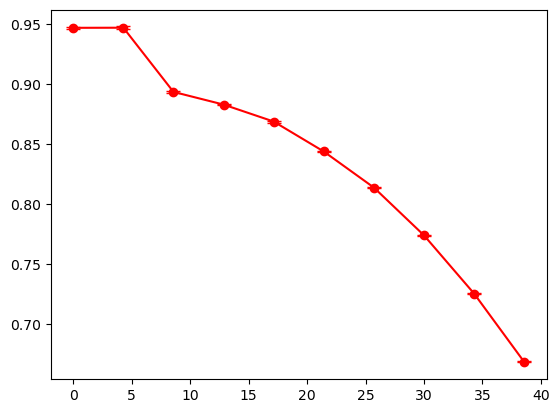

In [ ]:

keff_100 = [0.9164114672179005, 0.8473747445221763, 0.8167784900095804, 0.7851200403444879, 0.7551512967869326, 0.7214886594951482, 0.686628541799777, 0.6434980827890494, 0.5965162694202613]
keff_100_err = [0.0007952820466524422, 0.0006305735025148555, 0.000625471008416775, 0.0006136950637971477, 0.0006184542303602417, 0.000595045019042615, 0.0005219691768578445, 0.000486032546926751, 0.00041381955813641713]  # Supposition d'incertitude constante

keff_values.append(keff_100)
keff_errors.append(keff_100_err)

for i, (label, (keff_values, keff_errors)) in enumerate(results.items()):
    plt.errorbar(burnup_points, keff_values, yerr=keff_errors, fmt='o-', capsize=5, label=label, color=colors[i+1])
